In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.attractor_networks import ToroidZhang1996
import os

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

Ran warm up for 538 steps


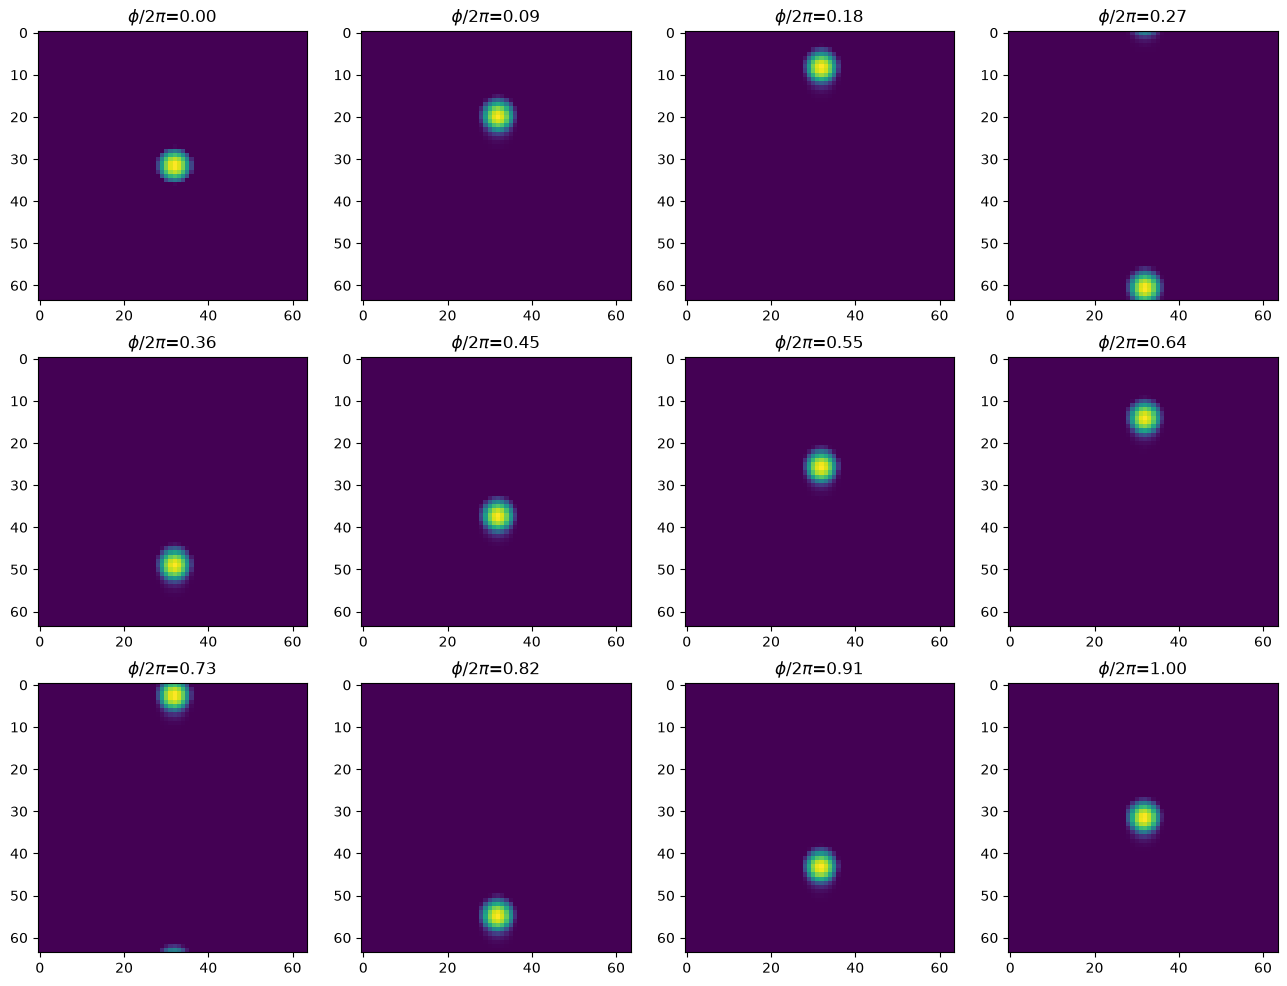

In [2]:
## Simulation parameters:
n_min_plots = 10
dt = 0.5e-3
n = 64

net = ToroidZhang1996(
    n=n, dt=dt, periodicity=18, revolutions=(2, 0), use_single_bump=True
)
net.s[n // 2, n // 2] = 10
net.warm_up()
ncols = np.int64(np.ceil(np.sqrt(n_min_plots)))
nrows = np.int64(np.ceil(n_min_plots / ncols))
n_plots = nrows * ncols
fig, ax = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
ax = ax.flatten()
phi = 0
omega = 5
n_steps = int((2 * np.pi) / omega / dt)
records = np.linspace(0, n_steps - 1, n_plots, dtype=int)
plot_counter = 0
time = 0


for step_iter in range(n_steps):
    if step_iter == records[plot_counter]:
        ax[plot_counter].imshow(net.s)
        ax[plot_counter].set_title(f"$\\phi/2\\pi$={phi/(2*np.pi):.2f}")
        plot_counter += 1

    net.step(omega, omega)
    phi += omega * dt
    time += dt

In [3]:
T = 400
dt = 0.5e-3
n = 64
net = ToroidZhang1996(
    n=n, dt=dt, periodicity=18, revolutions=(1, 1), use_single_bump=True
)
net.warm_up()
bat_flight = generate_bat_flight(T=T, dt=dt)
n_steps = bat_flight["pos"].shape[0]
recorded_cells = list(np.random.randint(0, n - 1, size=(9, 2)))

recording = net.run_simulation(bat_flight["dir_vel"])

Ran warm up for 1564 steps


Running Simulation Steps: 100%|██████████| 800000/800000 [03:43<00:00, 3585.79it/s]


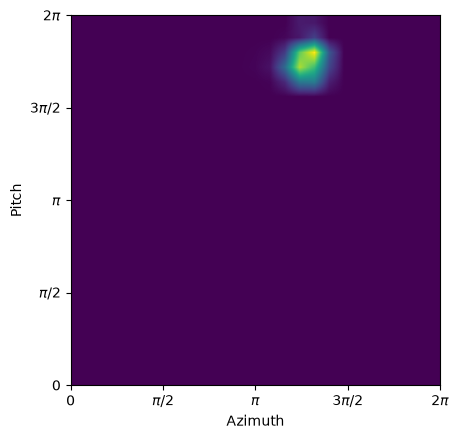

In [4]:
from grid_cells.plot_tools import activity_map

cell_index = 3

direction_activity_map, counts, direction_edges = activity_map(
    bat_flight["dir_torus"], recording["cell_recording"][:, cell_index], nbins=25
)
fig, ax = plt.subplots()
ax.imshow(
    direction_activity_map,
    extent=(
        direction_edges[0][0],
        direction_edges[0][-1],
        direction_edges[1][0],
        direction_edges[1][-1],
    ),
    interpolation="bilinear",
    origin="lower",
)
ax.set_xlabel("Azimuth")
ax.set_ylabel("Pitch")
ax.set_xticks(np.arange(0, 2.5, 0.5) * np.pi)
ax.set_xticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])
ax.set_yticks(np.arange(0, 2.5, 0.5) * np.pi)
ax.set_yticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_3d_direction_single_bump_periodic.png"))